<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. Intro: ConvNet on CIFAR10
Use PyTorch, start with a CPU, switch to GPU if it gets slow.

Implement a simple convolutional neural network for classifying the CIFAR10 dataset (32×32 RGB images, 10 classes).
- Use a train, val, test split of 3k, 3k, 3k images respectively.
- Train the neural network for ~30 epochs with the AdamW optimizer and a batch size of 64.
- Prevent overfitting using a) dropout and b) data augmentation.
- Add test-time augmentations (TTA).

In [15]:
import random
import time
from collections.abc import Callable
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import v2
from tqdm import tqdm

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

# Check for CUDA / MPS (Apple) / XPU (Intel) / ... (not XLA (Google TPUs), though).
device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)

cpu


### Datasets

In [16]:
dataset_path = Path("./data/CIFAR10/")
dataset_path.mkdir(parents=True, exist_ok=True)


mean, std = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
image_transform = v2.Compose([
    v2.ToImage(),  # shape (C,H,W), RGB 0..255
    v2.ToDtype(torch.float32, scale=True),  # 0..1 values
    v2.Normalize(mean, std),
])

train_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=True, download=True, transform=image_transform
)
val_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=True, download=True, transform=image_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=False, download=True, transform=image_transform
)
classes = train_dataset.classes
print("Classes:", classes)
print("Original lengths:", len(train_dataset), len(val_dataset), len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Original lengths: 50000 50000 10000


In [17]:
image, label = train_dataset[0]
print("Image shape:", image.shape, "dtype:", image.dtype)
print("Label type:", type(label))

Image shape: torch.Size([3, 32, 32]) dtype: torch.float32
Label type: <class 'int'>


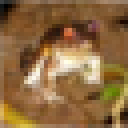

'frog'

In [20]:
to_pil_image = v2.Compose([
    v2.Normalize([-m/s for m, s in zip(mean, std)], [1/s for s in std]),
    v2.ToPILImage(),
    v2.Resize(128, interpolation=v2.InterpolationMode.NEAREST)
])

display(to_pil_image(image), classes[label])

In [42]:
# TODO limit to 3k each.
all_indices = list(range(len(train_dataset)))
np.random.default_rng(42).shuffle(all_indices)
test_dataset = Subset(test_dataset, all_indices[:3000])
val_dataset = Subset(val_dataset, all_indices[3000:6000])
train_dataset = Subset(train_dataset, all_indices[6000:9000])

print("New lengths:", len(train_dataset), len(val_dataset), len(test_dataset))

New lengths: 0 0 3000


### Dataloaders

In [22]:
pin_memory = device.type == "cuda"
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=pin_memory
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=pin_memory
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=pin_memory
)

In [23]:
# Get some random training batch.
image_batch, label_batch = next(iter(train_loader))

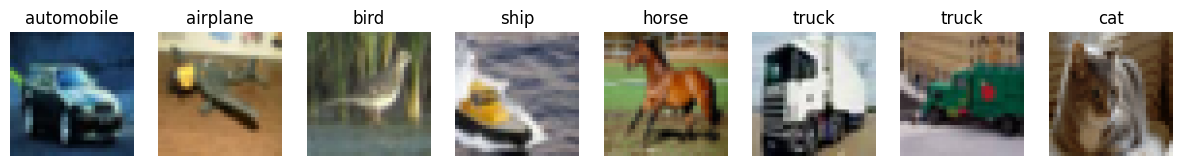

In [27]:
def show_images(images: torch.Tensor, labels: list[int], limit: int = 8) -> None:
    # TODO
    fig, axes = plt.subplots(nrows=1, ncols=limit, figsize=(15,2))
    for i in range(limit):
      axes[i].imshow(to_pil_image(images[i]))
      axes[i].set_title(classes[labels[i].item()])
      axes[i].axis("off")


show_images(image_batch, label_batch)

### Model
Start with: conv 32, conv 64, conv 128 (all with kernel size 3x3, stride 2 and padding 1), ReLU activations, a hidden linear layer 40 with relu, and linear output

In [ ]:
C, H, W = image.shape  # 3, 32, 32
print(C, H, W)

3 32 32


In [31]:
class Net(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # (32, 16, 16)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # (64, 8, 8)
            nn.ReLU(),
            nn.Conv2d(64, 2*64, kernel_size=3, stride=2, padding=1), # (128, 4, 4)
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*4*4, 40),
            nn.ReLU(),
            nn.Linear(40, num_classes),

        )
        # TODO

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO
        return self.layers(x)

In [44]:
class NetWithTTA(nn.Module):
    """Wrapper that applies test-time augmentation (TTA) to a model."""

    def __init__(self, net: Net, repeats: int = 3) -> None:
        super().__init__()
        self.net = net
        self.repeats = repeats
        # TODO
        self.augumentations = v2.Compose([
            v2.RandomHorizontalFlip(),
            v2.RandomRotation(degrees=15)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO
        if self.training:
          return self.net(x)
        x = torch.cat([self.augumentations(x) for _ in range(self.repeats)])
        logits = net(x)
        logits = logits.view(self.repeats, -1, 10)
        return logits.mean(dim=0)


### Training
Start TensorBoard (at the end of this notebook) before running the training.

In [29]:
from torch.utils.tensorboard import SummaryWriter

global_step = 0


def evaluate(net: nn.Module, dataloader: DataLoader) -> tuple[float, float]:
    """Return (loss, accuracy)."""
    net.eval()
    correct, total_loss, total = 0, 0.0, 0
    with torch.no_grad():
        for image, label in tqdm(dataloader, "Evaluate"):
            image, label = image.to(device), label.to(device)
            logits = net(image)
            loss = nn.CrossEntropyLoss(reduction="sum")(logits, label)
            predicted = logits.argmax(dim=1)
            correct += (predicted == label).sum().item()
            total_loss += loss.item()
            total += label.size(0)
    return (
        total_loss / total,
        correct / total,
    )


def train_epoch(
    net: nn.Module,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    writer: SummaryWriter,
    desc: str,
) -> None:
    global global_step
    net.train()
    for image, label in tqdm(train_loader, desc):
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        logits = net(image)
        loss = nn.CrossEntropyLoss()(logits, label)
        loss.backward()
        optimizer.step()
        writer.add_scalar("train/loss", loss.item(), global_step)
        global_step += 1


def train(
    net: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    name: str,
) -> None:
    global global_step
    global_step = 0
    writer = SummaryWriter(log_dir=f"runs/{name}_{time.strftime('%H%M')}")

    optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(epochs):
        train_epoch(net, train_loader, optimizer, writer, f"Epoch {epoch + 1}/{epochs}")
        val_loss, val_acc = evaluate(net, val_loader)
        writer.add_scalar("val/loss", val_loss, global_step)
        writer.add_scalar("val/accuracy", val_acc, global_step)

In [32]:
net = Net().to(device)
#net = NetWithTTA(net)
train(net, train_loader, val_loader, epochs=40, name="basic")

Evaluate: 100%|██████████| 47/47 [00:01<00:00, 24.78it/s]


In [33]:
checkpoint_path = Path("./cifar_net.pth")
torch.save(net.state_dict(), checkpoint_path)

In [46]:
class NetWithTTA(nn.Module):
    def __init__(self, net: nn.Module, repeats: int = 3) -> None:
        super().__init__()
        self.net = net
        self.repeats = repeats
        self.augumentations = v2.Compose([
            v2.RandomHorizontalFlip(),
            v2.RandomRotation(degrees=15)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            return self.net(x)

        # Pobieramy rozmiar batcha (B)
        batch_size = x.size(0)

        # 1. Tworzymy listę augmentowanych wersji
        # 2. Używamy stack, żeby mieć wymiar [repeats, B, C, H, W]
        x_augmented = torch.stack([self.augumentations(x) for _ in range(self.repeats)])

        # 3. Spłaszczamy pierwsze dwa wymiary, żeby przepuścić przez sieć jednym strzałem
        # Nowy kształt: [repeats * B, C, H, W]
        x_flattened = x_augmented.view(-1, *x.shape[1:])

        # 4. Jeden forward przez sieć (szybciej niż pętla for z forwardem)
        logits = self.net(x_flattened)

        # 5. Przywracamy wymiar repeats i uśredniamy
        # logits po forward ma [repeats * B, num_classes]
        logits = logits.view(self.repeats, batch_size, -1)

        return logits.mean(dim=0)

In [47]:
net = Net().to(device)
net = NetWithTTA(net)
train(net, train_loader, val_loader, epochs=40, name="basic")

Evaluate: 100%|██████████| 47/47 [00:02<00:00, 18.48it/s]


In [40]:
net = Net().to(device)
net = NetWithTTA(Net()).to(device)
net.load_state_dict(torch.load(checkpoint_path, map_location=device))

RuntimeError: Error(s) in loading state_dict for NetWithTTA:
	Missing key(s) in state_dict: "net.layers.0.weight", "net.layers.0.bias", "net.layers.2.weight", "net.layers.2.bias", "net.layers.4.weight", "net.layers.4.bias", "net.layers.7.weight", "net.layers.7.bias", "net.layers.9.weight", "net.layers.9.bias". 
	Unexpected key(s) in state_dict: "layers.0.weight", "layers.0.bias", "layers.2.weight", "layers.2.bias", "layers.4.weight", "layers.4.bias", "layers.7.weight", "layers.7.bias", "layers.9.weight", "layers.9.bias". 

In [38]:
train_loss, train_acc = evaluate(net, train_loader)
val_loss, val_acc = evaluate(net, val_loader)
test_loss, test_acc = evaluate(net, test_loader)
print(f"accuracy on train: {train_acc:.1%}, val: {val_acc:.1%}, test: {test_acc:.1%}")

Evaluate:   0%|          | 0/47 [00:00<?, ?it/s]


IndexError: index 24774 is out of bounds for axis 0 with size 10000

### TensorBoard

In [ ]:
%load_ext tensorboard
# Sometimes you might need to run this cell twice.
%tensorboard --logdir runs